# Peak Tracking Analysis

Loads all `tracking_results_long.csv` outputs from `peak_tracking_workflow_outputs`,
combines them into a single DataFrame, and parses the run name into condition columns
for easy filtering.

In [10]:
from pathlib import Path
import re
import pandas as pd

In [11]:
OUTPUT_ROOT = Path(
    r"G:\Shared drives\Sutter-Fella Lab\ALS_Beamtimes\2026\Yi-Ru_Feb2026\processed\peak_tracking_workflow_outputs"
)

## Load all CSVs

For each run name, pick the **latest** timestamped output folder so re-runs don't double-count.

In [30]:
# Group folders by run name (strip the trailing _YYYYMMDD_HHMMSS timestamp)
_TIMESTAMP_RE = re.compile(r"_\d{8}_\d{6}$")

latest: dict[str, Path] = {}
for folder in sorted(OUTPUT_ROOT.iterdir()):  # sorted → later timestamps win
    if not folder.is_dir():
        continue
    run_name = _TIMESTAMP_RE.sub("", folder.name)
    latest[run_name] = folder

print(f"Found {len(latest)} runs:")
for name, folder in sorted(latest.items()):
    print(f"  {name}  →  {folder.name}")

Found 11 runs:
  aging_100c_120s_anneal_ClMBAI  →  aging_100c_120s_anneal_ClMBAI_20260525_185019
  aging_100c_120s_anneal_MBAI  →  aging_100c_120s_anneal_MBAI_20260525_185019
  aging_100c_120s_anneal_MeOMBAI  →  aging_100c_120s_anneal_MeOMBAI_20260525_185019
  aging_120c_120s_anneal_ClMBAI  →  aging_120c_120s_anneal_ClMBAI_20260525_191807
  aging_120c_120s_anneal_MeOMBAI  →  aging_120c_120s_anneal_MeOMBAI_20260525_185019
  aging_120c_70s_anneal_ClMBAI  →  aging_120c_70s_anneal_ClMBAI_20260525_185019
  aging_120c_70s_anneal_MeOMBAI  →  aging_120c_70s_anneal_MeOMBAI_20260525_185019
  insitu_0.5M_ClMBAI  →  insitu_0.5M_ClMBAI_20260525_185019
  insitu_0.5M_MBAI  →  insitu_0.5M_MBAI_20260525_232847
  insitu_0.5M_MeOMBAI  →  insitu_0.5M_MeOMBAI_20260526_001029
  stage_logs  →  stage_logs


In [31]:
stage_logs_dict = {}

if 'stage_logs' in latest:
    stage_logs = list(latest['stage_logs'].glob("*.csv"))
    for log_path in stage_logs:
        stage_logs_dict[log_path.stem] = log_path

    # remove the stage_logs entry from latest since we've extracted the logs
    del latest['stage_logs']

print("\nStage logs found:")
for name, log_path in sorted(stage_logs_dict.items()):
    print(f"  {name}  →  {log_path.name}")


Stage logs found:
  aging_100c_120s_anneal_ClMBAI  →  aging_100c_120s_anneal_ClMBAI.csv
  aging_100c_120s_anneal_MBAI  →  aging_100c_120s_anneal_MBAI.csv
  aging_100c_120s_anneal_MeOMBAI  →  aging_100c_120s_anneal_MeOMBAI.csv
  aging_120c_120s_anneal_ClMBAI  →  aging_120c_120s_anneal_ClMBAI.csv
  aging_120c_120s_anneal_MeOMBAI  →  aging_120c_120s_anneal_MeOMBAI.csv
  aging_120c_70s_anneal_ClMBAI  →  aging_120c_70s_anneal_ClMBAI.csv
  aging_120c_70s_anneal_MeOMBAI  →  aging_120c_70s_anneal_MeOMBAI.csv
  insitu_0.5M_ClMBAI  →  insitu_0.5M_ClMBAI.csv
  insitu_0.5M_MBAI  →  insitu_0.5M_MBAI.csv
  insitu_0.5M_MeOMBAI  →  insitu_0.5M_MeOMBAI.csv


In [34]:
frames = []
for run_name, folder in sorted(latest.items()):
    csv_path = folder / "tracking_results_long.csv"
    if not csv_path.exists():
        print(f"  WARNING: no CSV in {folder.name}")
        continue
    df_run = pd.read_csv(csv_path)

    if run_name in stage_logs_dict:
        df_stage = pd.read_csv(stage_logs_dict[run_name], comment="#")  # skip metadata comment lines
        # join by frame_index of df_run and frame_number of df_stage
        df_run = df_run.merge(
            df_stage,
            left_on="frame_index",
            right_on="frame_number",
            how="left",
        )

        # replace time columns with `Time (s)` from stage log
        if "Time (s)" in df_run.columns:
            df_run["time"] = df_run["Time (s)"]
            df_run.drop(columns=["Time (s)"], inplace=True)
        else:
            print(f"  WARNING: no 'Time (s)' column in stage log for {run_name}")

    frames.append(df_run)

df_raw = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(df_raw):,} rows from {len(frames)} runs")
df_raw.head(2)

Loaded 25,596 rows from 10 runs


,time,frame_index,is_config_key_frame,is_auto_key_frame,is_key_frame,peak_name,expected_center_deg,candidate_center_deg,fit_center_deg,drift_tolerance_deg,...,Load Stage LVDT,Centroid Intensity,Video Background,Absolute Horz Centroid,Absolute Vertical Centroid,LabVIEW Memory,Fake Motor 1,Fake Motor 2,Pilatus,frame_number
0,1313.213,866,False,True,True,2D (002),6.4,6.132531,6.133381,0.05,...,0.0,0.0,0.0,0.0,0.0,1831576.0,0.0,0.0,..\ClMBAI_aging_from_100C_2min_anneal 004915 I...,866.0
1,1311.455,865,False,False,False,2D (002),6.4,6.132531,6.132700,0.05,...,0.0,0.0,0.0,0.0,0.0,1830236.0,0.0,0.0,..\ClMBAI_aging_from_100C_2min_anneal 004915 I...,865.0


## Parse condition columns from `run_name`

| Column | Values | Notes |
|--------|--------|-------|
| `experiment_type` | `aging` / `insitu` | |
| `sample` | `MBAI` / `ClMBAI` / `MeOMBAI` | |
| `anneal_temp_c` | `100` / `120` / NaN | aging only |
| `anneal_time_s` | `70` / `120` / NaN | aging only |
| `concentration_M` | `0.5` / NaN | insitu only |

In [37]:
# Pattern: aging_{temp}c_{time}s_anneal_{sample}
_AGING_RE = re.compile(
    r"^aging_(?P<temp>\d+)c_(?P<time>\d+)s_anneal_(?P<sample>.+)$"
)
# Pattern: insitu_{conc}M_{sample}  (conc uses 'p' as decimal: 0p5 → 0.5)
_INSITU_RE = re.compile(
    r"^insitu_(?P<conc>[\d.]+)M_(?P<sample>.+)$"
)


def _parse_run_name(name: str) -> dict:
    m = _AGING_RE.match(name)
    if m:
        return {
            "experiment_type": "aging",
            "sample": m.group("sample"),
            "anneal_temp_c": int(m.group("temp")),
            "anneal_time_s": int(m.group("time")),
            "concentration_M": float("nan"),
        }
    m = _INSITU_RE.match(name)
    if m:
        return {
            "experiment_type": "insitu",
            "sample": m.group("sample"),
            "anneal_temp_c": float("nan"),
            "anneal_time_s": float("nan"),
            "concentration_M": float(m.group("conc")),
        }
    # Fallback — keep run_name, set rest to NaN
    return {
        "experiment_type": None,
        "sample": None,
        "anneal_temp_c": float("nan"),
        "anneal_time_s": float("nan"),
        "concentration_M": float("nan"),
    }


cond_df = df_raw["run_name"].map(_parse_run_name).apply(pd.Series)
df = pd.concat([df_raw, cond_df], axis=1)

# Tidy dtypes
df["anneal_temp_c"] = pd.to_numeric(df["anneal_temp_c"], errors="coerce")
df["anneal_time_s"] = pd.to_numeric(df["anneal_time_s"], errors="coerce")
df["concentration_M"] = pd.to_numeric(df["concentration_M"], errors="coerce")

print("Condition value counts:")
for col in ["experiment_type", "sample", "anneal_temp_c", "anneal_time_s", "concentration_M"]:
    print(f"  {col}: {df[col].value_counts(dropna=False).to_dict()}")


# clean up
df = df.copy() # avoid PerformanceWarning later
df.head(3)

Condition value counts:
  experiment_type: {'aging': 15001, 'insitu': 10595}
  sample: {'ClMBAI': 10006, 'MeOMBAI': 8790, 'MBAI': 6800}
  anneal_temp_c: {nan: 10595, 100.0: 9211, 120.0: 5790}
  anneal_time_s: {120.0: 12255, nan: 10595, 70.0: 2746}
  concentration_M: {nan: 15001, 0.5: 10595}


,time,frame_index,is_config_key_frame,is_auto_key_frame,is_key_frame,peak_name,expected_center_deg,candidate_center_deg,fit_center_deg,drift_tolerance_deg,...,LabVIEW Memory,Fake Motor 1,Fake Motor 2,Pilatus,frame_number,experiment_type,sample,anneal_temp_c,anneal_time_s,concentration_M
0,1313.213,866,False,True,True,2D (002),6.4,6.132531,6.133381,0.05,...,1831576.0,0.0,0.0,..\ClMBAI_aging_from_100C_2min_anneal 004915 I...,866.0,aging,ClMBAI,100.0,120.0,NaN
1,1311.455,865,False,False,False,2D (002),6.4,6.132531,6.132700,0.05,...,1830236.0,0.0,0.0,..\ClMBAI_aging_from_100C_2min_anneal 004915 I...,865.0,aging,ClMBAI,100.0,120.0,NaN
2,1309.775,864,False,False,False,2D (002),6.4,6.132531,6.133293,0.05,...,1882144.0,0.0,0.0,..\ClMBAI_aging_from_100C_2min_anneal 004915 I...,864.0,aging,ClMBAI,100.0,120.0,NaN


## Example filters

Text(0.5, 1.0, 'PbI2 Int. Area Over Time')

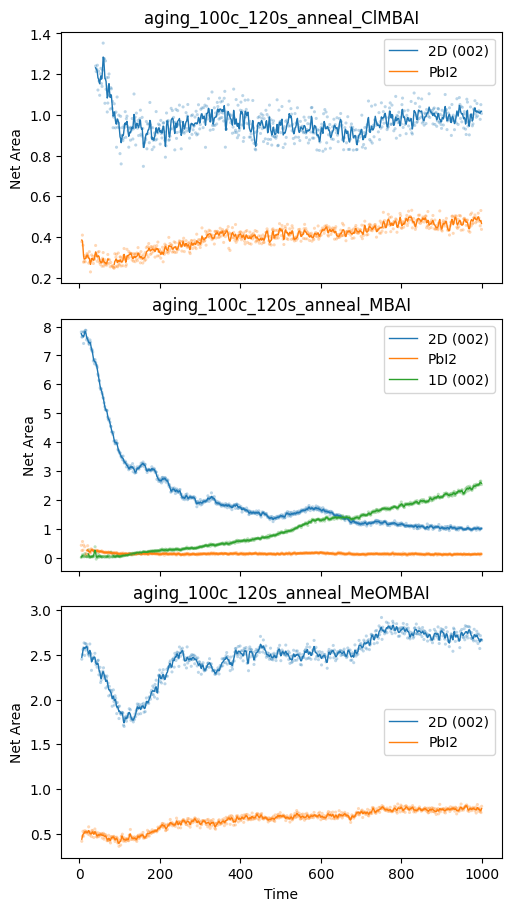

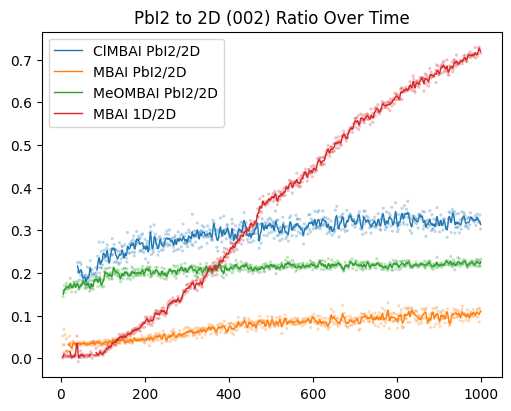

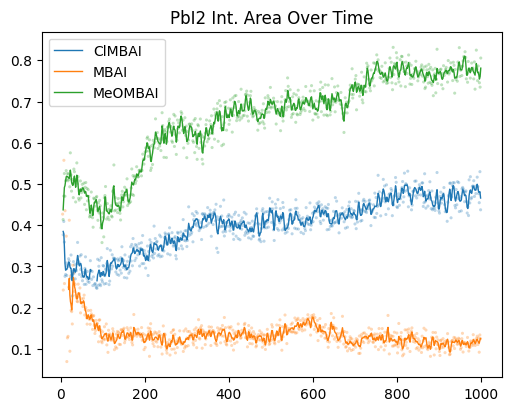

In [38]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


aging_100c_120s = df[(df["experiment_type"] == "aging") & (df["anneal_temp_c"] == 100) & (df["anneal_time_s"] == 120)]

# cutoff at 1000s
aging_100c_120s = aging_100c_120s[aging_100c_120s["time"] <= 1000]

# remove unwanted peaks
drop_peaks = ["ClMBAI", "ITO", "MeOMBAI"]
aging_100c_120s = aging_100c_120s[~aging_100c_120s["peak_name"].isin(drop_peaks)]

# group by run_name plot each group separately
run_groups = aging_100c_120s.groupby("run_name")

fig, axes = plt.subplots(nrows=len(run_groups), ncols=1, figsize=(5, 3 * len(run_groups)), sharex=True, constrained_layout=True)

for (run_name, group), ax in zip(run_groups, axes.flatten()):
    # plot each peak in the group as a separate line plot

    # show lines in specified order (2D, PbI2, then 1D (if present))
    plot_order = ["2D (002)", "PbI2", "1D (002)"]
    group_peak_names = group["peak_name"].unique()
    plot_order = [p for p in plot_order if p in group_peak_names]
    grouped = group.set_index("peak_name").loc[plot_order].reset_index()

    for peak_name, peak_group in grouped.groupby("peak_name", sort=False):
        ax.scatter(peak_group["time"], peak_group["net_area"], alpha=0.3, s=5, edgecolor='none')
        smooth_data = gaussian_filter1d(peak_group["net_area"], sigma=1)
        ax.plot(peak_group["time"], smooth_data, label=peak_name, linewidth=1)

    ax.set_title(run_name)
    ax.set_ylabel("Net Area")
    ax.legend()

axes[-1].set_xlabel("Time")

# Second plot: PbI2 to 2D ratios of all samples on the same plot plus 1D (002) to 2D ratios if present
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
for (run_name, group) in aging_100c_120s.groupby("run_name"):

    # use sample as label instead of run_name
    sample = group["sample"].iloc[0]

    # get PbI2 and 2d peaks
    pb_peak = group[group["peak_name"] == "PbI2"]
    d2_peak = group[group["peak_name"] == "2D (002)"]
    
    # merge on time to get ratios
    merged = pd.merge(pb_peak[["time", "net_area"]], d2_peak[["time", "net_area"]], on="time", suffixes=("_pb", "_d2"))
    merged["ratio"] = merged["net_area_pb"] / (merged["net_area_d2"] + merged["net_area_pb"])
    
    ax.scatter(merged["time"], merged["ratio"], alpha=0.3, s=5, edgecolor='none')
    smooth_ratio = gaussian_filter1d(merged["ratio"], sigma=1)
    ax.plot(merged["time"], smooth_ratio, linewidth=1, label=f"{sample} PbI2/2D" )

for (run_name, group) in aging_100c_120s.groupby("run_name"):
    if "1D (002)" in group["peak_name"].values:
        sample = group["sample"].iloc[0]
        d1_peak = group[group["peak_name"] == "1D (002)"]
        d2_peak = group[group["peak_name"] == "2D (002)"]
        merged_d1 = pd.merge(d1_peak[["time", "net_area"]], d2_peak[["time", "net_area"]], on="time", suffixes=("_d1", "_d2"))
        merged_d1["ratio"] = merged_d1["net_area_d1"] / (merged_d1["net_area_d2"] + merged_d1["net_area_d1"])
        
        ax.scatter(merged_d1["time"], merged_d1["ratio"], alpha=0.3, s=5, edgecolor='none')
        smooth_ratio_d1 = gaussian_filter1d(merged_d1["ratio"], sigma=1)
        ax.plot(merged_d1["time"], smooth_ratio_d1, linewidth=1, label=f"{sample} 1D/2D")

ax.legend()
ax.set_title("PbI2 to 2D (002) Ratio Over Time")

# third plot: PbI2 net_area all samples on the same plot
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
for (run_name, group) in aging_100c_120s.groupby("run_name"):
    sample = group["sample"].iloc[0]
    pb_peak = group[group["peak_name"] == "PbI2"]
    ax.scatter(pb_peak["time"], pb_peak["net_area"], alpha=0.3, s=5, edgecolor='none')
    smooth_pb = gaussian_filter1d(pb_peak["net_area"], sigma=1)
    ax.plot(pb_peak["time"], smooth_pb, linewidth=1, label=sample)

ax.legend()
ax.set_title("PbI2 Int. Area Over Time")

<StringArray>
['2D (002)', 'PbI2', 'ITO']
Length: 3, dtype: str
<StringArray>
['2D (002)', 'PbI2', 'ITO']
Length: 3, dtype: str
<StringArray>
['2D (002)', 'PbI2', 'ITO']
Length: 3, dtype: str


Text(0.5, 0, 'Time')

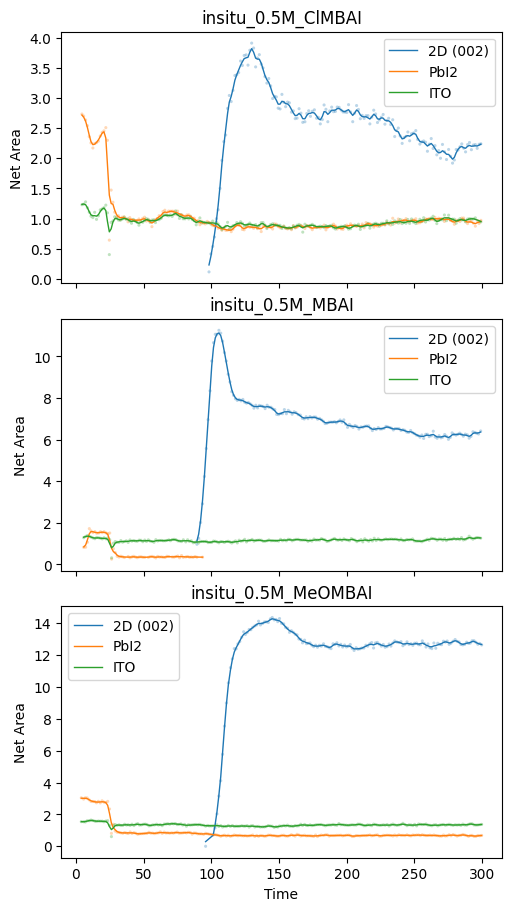

In [39]:
# plot insitu samples with same plotting code as above

insitu_samples = df[df["experiment_type"] == "insitu"]

# filter to 900s
insitu_samples = insitu_samples[(insitu_samples["time"] <= 300) & (insitu_samples["fit_r2"] > 0.9)]

# addtional filter to for ClMBAI-2D peak with low R2 values that are likely bad fits (based on visual inspection of the data)
insitu_samples = insitu_samples[~((insitu_samples["peak_name"] == "2D (002)") & (insitu_samples["sample"] == "ClMBAI") & (insitu_samples["fit_r2"] < 0.95))]

peaks_to_drop = ["ClMBAI", "MeOMBAI"]
insitu_samples = insitu_samples[~insitu_samples["peak_name"].isin(peaks_to_drop)]

fig, axes = plt.subplots(nrows=len(run_groups), ncols=1, figsize=(5, 3 * len(run_groups)), sharex=True, constrained_layout=True)

run_groups = insitu_samples.groupby("run_name")

for (sample_name, group), ax in zip(run_groups, axes.flatten()):

    # show lines in specified order (2D, PbI2, then 1D (if present))
    plot_order = ["2D (002)", "PbI2", "ITO", "1D (002)"]
    group_peak_names = group["peak_name"].unique()
    print(group["peak_name"].unique())
    plot_order = [p for p in plot_order if p in group_peak_names]
    grouped = group.set_index("peak_name").loc[plot_order].reset_index()

    for peak_name, peak_group in grouped.groupby("peak_name", sort=False):

        ax.scatter(peak_group["time"], peak_group["net_area"], alpha=0.3, s=5, edgecolor='none')
        # remove nan values before smoothing by creating a series then drop na rows
        net_area_clean_series = pd.Series(peak_group["net_area"]).set_axis(peak_group["time"])
        net_area_clean_series = net_area_clean_series.dropna()
        smooth_data = gaussian_filter1d(net_area_clean_series, sigma=1)
        ax.plot(net_area_clean_series.index, smooth_data, label=peak_name, linewidth=1)

    ax.set_title(sample_name)
    ax.legend()
    ax.set_ylabel("Net Area")

axes[-1].set_xlabel("Time")


In [121]:
# All in-situ runs, 2D (002) peak only, successful fits
insitu_2d = df[
    (df["experiment_type"] == "insitu")
    & (df["peak_name"] == "2D (002)")
    & df["fit_success"]
]
print(f"{len(insitu_2d):,} rows — in-situ 2D (002) successful fits")
insitu_2d[["run_name", "sample", "time", "fit_center_deg", "net_area", "fit_r2"]].head(6)

2,610 rows — in-situ 2D (002) successful fits


,run_name,sample,time,fit_center_deg,net_area,fit_r2
13032,insitu_0.5M_ClMBAI,ClMBAI,1268.341717,6.402904,2.578114,0.982862
13033,insitu_0.5M_ClMBAI,ClMBAI,1266.587528,6.402722,2.690591,0.982954
13034,insitu_0.5M_ClMBAI,ClMBAI,1265.081941,6.403672,2.634727,0.984906
13035,insitu_0.5M_ClMBAI,ClMBAI,1263.477512,6.401118,2.602423,0.986992
13036,insitu_0.5M_ClMBAI,ClMBAI,1261.922004,6.400840,2.644603,0.982079
13037,insitu_0.5M_ClMBAI,ClMBAI,1260.244693,6.401730,2.740573,0.983162


In [122]:
# All aging ClMBAI runs — compare anneal conditions
aging_cl = df[
    (df["experiment_type"] == "aging")
    & (df["sample"] == "ClMBAI")
    & (df["peak_name"] == "2D (002)")
    & df["fit_success"]
]
print(f"{len(aging_cl):,} rows — aging ClMBAI 2D (002) by anneal condition")
aging_cl.groupby(["anneal_temp_c", "anneal_time_s"])["net_area"].describe().round(2)

1,312 rows — aging ClMBAI 2D (002) by anneal condition


count   mean   std    min    25%    50%    75%  \
anneal_temp_c anneal_time_s                                                   
100.0         120.0          842.0   1.01  0.12   0.75   0.93   0.99   1.06   
120.0         70.0           248.0  10.80  0.47   9.13  10.53  10.86  11.17   
              120.0          222.0  23.75  0.50  23.07  23.54  23.70  23.85   

                               max  
anneal_temp_c anneal_time_s         
100.0         120.0           1.43  
120.0         70.0           11.80  
              120.0          27.57

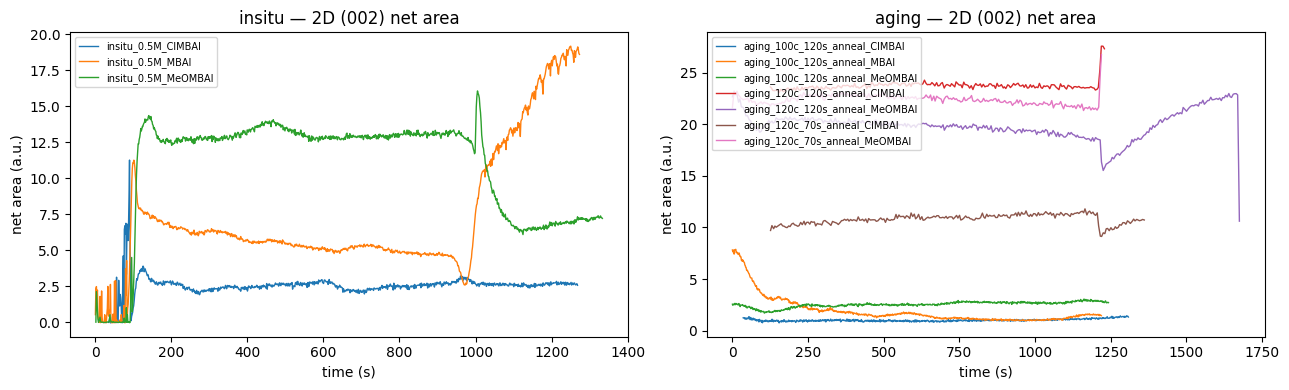

In [123]:
# Pivot: net_area vs time for each run (2D (002) only, successful fits)
d2d = df[(df["peak_name"] == "2D (002)") & df["fit_success"]].copy()

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, exp_type in zip(axes, ["insitu", "aging"]):
    subset = d2d[d2d["experiment_type"] == exp_type]
    for run, grp in subset.groupby("run_name"):
        grp_sorted = grp.sort_values("time")
        ax.plot(grp_sorted["time"], grp_sorted["net_area"], label=run, lw=1)
    ax.set_title(f"{exp_type} — 2D (002) net area")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("net area (a.u.)")
    ax.legend(fontsize=7, loc="upper left")

fig.tight_layout()
plt.show()